#Δημιουργία των Dataset με τα Profiles για τις 6 χώρες Ελλάδα, Γερμανία, Γαλλία, Σουηδία, Ρουμανία και Τσεχία

#Profiles in Greece

Αντιστοιχία με τα highly green occupations

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_greece_green_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Greece"]

# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
green_occupation_uris_set = set(green_occupation_uris)
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

OCCUPATION_URIS = green_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Greece' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "Greece" and profile.get("country") != "Greece":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & green_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} green occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Greece]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Greece + green occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Greece'], occupation_uris=(152 green occupation URIs, logic=or)


Fetching profiles [Greece]: 100%|██████████| 4913/4913 [14:41<00:00,  5.57profile/s, matched=4913, pages=99]


✅ API reported total profiles returned by server-side filters: 4913
✅ Profiles fetched/inspected: 4913
✅ Profiles that passed the client-side check (Greece + green occupation): 4913
✅ Saved profile data to skillab_profiles_greece_green_occupations.json


Αντιστοιχία με τα green skills

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_greece_green_skills.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Greece"]

# Φόρτωση της λίστας green skills (ESCO)
green_skills_df = pd.read_csv("/content/greenSkillsCollection_en.csv")
green_skill_uris = green_skills_df["conceptUri"].dropna().unique().tolist()
green_skill_uris_set = set(green_skill_uris)
print(f"Επίσημα green skill URIs: {len(green_skill_uris)}")

SKILL_IDS = green_skill_uris
SKILL_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Greece' ΚΑΙ τουλάχιστον ένα
    κοινό skill URI με τη λίστα των πράσινων skills (πεδίο 'skills' — επιβεβαιωμένο
    από το API response schema)."""
    if profile.get("location") != "Greece" and profile.get("country") != "Greece":
        return False
    profile_skill_uris = set(profile.get("skills") or [])
    return bool(profile_skill_uris & green_skill_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "skill_ids": SKILL_IDS,
    "skill_ids_logic": SKILL_IDS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, skill_ids=({len(SKILL_IDS)} green skill URIs, logic={SKILL_IDS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Greece]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Greece + green skill): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green skill URIs: 629
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Greece'], skill_ids=(629 green skill URIs, logic=or)


Fetching profiles [Greece]: 100%|██████████| 2190/2190 [02:21<00:00, 15.50profile/s, matched=2190, pages=44]

✅ API reported total profiles returned by server-side filters: 2190
✅ Profiles fetched/inspected: 2190
✅ Profiles that passed the client-side check (Greece + green skill): 2190
✅ Saved profile data to skillab_profiles_greece_green_skills.json


#Profiles in Germany

Αντιστοιχία με τα highly green occupations

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_germany_green_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Germany"]

# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
green_occupation_uris_set = set(green_occupation_uris)
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

OCCUPATION_URIS = green_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Germany' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "Germany" and profile.get("country") != "Germany":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & green_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} green occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Germany]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Germany + green occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Germany'], occupation_uris=(152 green occupation URIs, logic=or)


Fetching profiles [Germany]: 100%|██████████| 34579/34579 [1:00:04<00:00,  9.59profile/s, matched=34579, pages=692]


✅ API reported total profiles returned by server-side filters: 34579
✅ Profiles fetched/inspected: 34579
✅ Profiles that passed the client-side check (Germany + green occupation): 34579
✅ Saved profile data to skillab_profiles_germany_green_occupations.json


Αντιστοιχία με τα green skills

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_germany_green_skills.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Germany"]

# Φόρτωση της λίστας green skills (ESCO)
green_skills_df = pd.read_csv("/content/greenSkillsCollection_en.csv")
green_skill_uris = green_skills_df["conceptUri"].dropna().unique().tolist()
green_skill_uris_set = set(green_skill_uris)
print(f"Επίσημα green skill URIs: {len(green_skill_uris)}")

SKILL_IDS = green_skill_uris
SKILL_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Germany' ΚΑΙ τουλάχιστον ένα
    κοινό skill URI με τη λίστα των πράσινων skills (πεδίο 'skills' — επιβεβαιωμένο
    από το API response schema)."""
    if profile.get("location") != "Germany" and profile.get("country") != "Germany":
        return False
    profile_skill_uris = set(profile.get("skills") or [])
    return bool(profile_skill_uris & green_skill_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "skill_ids": SKILL_IDS,
    "skill_ids_logic": SKILL_IDS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, skill_ids=({len(SKILL_IDS)} green skill URIs, logic={SKILL_IDS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Germany]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Germany + green skill): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green skill URIs: 629
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Germany'], skill_ids=(629 green skill URIs, logic=or)


Fetching profiles [Germany]: 100%|██████████| 9457/9457 [08:12<00:00, 19.22profile/s, matched=9457, pages=190]


✅ API reported total profiles returned by server-side filters: 9457
✅ Profiles fetched/inspected: 9457
✅ Profiles that passed the client-side check (Germany + green skill): 9457
✅ Saved profile data to skillab_profiles_germany_green_skills.json


#Profiles in France

Αντιστοιχία με τα highly green occupations

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_france_green_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["France"]

# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
green_occupation_uris_set = set(green_occupation_uris)
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

OCCUPATION_URIS = green_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'France' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "France" and profile.get("country") != "France":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & green_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} green occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [France]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (France + green occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['France'], occupation_uris=(152 green occupation URIs, logic=or)


Fetching profiles [France]: 100%|██████████| 54413/54413 [1:32:24<00:00,  9.81profile/s, matched=54413, pages=1089]


✅ API reported total profiles returned by server-side filters: 54413
✅ Profiles fetched/inspected: 54413
✅ Profiles that passed the client-side check (France + green occupation): 54413
✅ Saved profile data to skillab_profiles_france_green_occupations.json


Αντιστοιχία με τα green skills

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_france_green_skills.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["France"]

# Φόρτωση της λίστας green skills (ESCO)
green_skills_df = pd.read_csv("/content/greenSkillsCollection_en.csv")
green_skill_uris = green_skills_df["conceptUri"].dropna().unique().tolist()
green_skill_uris_set = set(green_skill_uris)
print(f"Επίσημα green skill URIs: {len(green_skill_uris)}")

SKILL_IDS = green_skill_uris
SKILL_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'France' ΚΑΙ τουλάχιστον ένα
    κοινό skill URI με τη λίστα των πράσινων skills (πεδίο 'skills' — επιβεβαιωμένο
    από το API response schema)."""
    if profile.get("location") != "France" and profile.get("country") != "France":
        return False
    profile_skill_uris = set(profile.get("skills") or [])
    return bool(profile_skill_uris & green_skill_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "skill_ids": SKILL_IDS,
    "skill_ids_logic": SKILL_IDS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, skill_ids=({len(SKILL_IDS)} green skill URIs, logic={SKILL_IDS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [France]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (France + green skill): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green skill URIs: 629
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['France'], skill_ids=(629 green skill URIs, logic=or)


Fetching profiles [France]: 100%|██████████| 7945/7945 [06:49<00:00, 19.42profile/s, matched=7945, pages=159]


✅ API reported total profiles returned by server-side filters: 7945
✅ Profiles fetched/inspected: 7945
✅ Profiles that passed the client-side check (France + green skill): 7945
✅ Saved profile data to skillab_profiles_france_green_skills.json


#Profiles in Sweden

Αντιστοιχία με τα highly green occupations

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_sweden_green_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Sweden"]

# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
green_occupation_uris_set = set(green_occupation_uris)
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

OCCUPATION_URIS = green_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Sweden' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "Sweden" and profile.get("country") != "Sweden":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & green_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} green occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Sweden]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Sweden + green occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Sweden'], occupation_uris=(152 green occupation URIs, logic=or)


Fetching profiles [Sweden]: 100%|██████████| 10141/10141 [16:50<00:00, 10.03profile/s, matched=10141, pages=203]


✅ API reported total profiles returned by server-side filters: 10141
✅ Profiles fetched/inspected: 10141
✅ Profiles that passed the client-side check (Sweden + green occupation): 10141
✅ Saved profile data to skillab_profiles_sweden_green_occupations.json


Αντιστοιχία με τα green skills

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_sweden_green_skills.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Sweden"]

# Φόρτωση της λίστας green skills (ESCO)
green_skills_df = pd.read_csv("/content/greenSkillsCollection_en.csv")
green_skill_uris = green_skills_df["conceptUri"].dropna().unique().tolist()
green_skill_uris_set = set(green_skill_uris)
print(f"Επίσημα green skill URIs: {len(green_skill_uris)}")

SKILL_IDS = green_skill_uris
SKILL_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Sweden' ΚΑΙ τουλάχιστον ένα
    κοινό skill URI με τη λίστα των πράσινων skills (πεδίο 'skills' — επιβεβαιωμένο
    από το API response schema)."""
    if profile.get("location") != "Sweden" and profile.get("country") != "Sweden":
        return False
    profile_skill_uris = set(profile.get("skills") or [])
    return bool(profile_skill_uris & green_skill_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "skill_ids": SKILL_IDS,
    "skill_ids_logic": SKILL_IDS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, skill_ids=({len(SKILL_IDS)} green skill URIs, logic={SKILL_IDS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Sweden]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Sweden + green skill): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green skill URIs: 629
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Sweden'], skill_ids=(629 green skill URIs, logic=or)


Fetching profiles [Sweden]: 100%|██████████| 3401/3401 [02:27<00:00, 22.98profile/s, matched=3401, pages=69]

✅ API reported total profiles returned by server-side filters: 3401
✅ Profiles fetched/inspected: 3401
✅ Profiles that passed the client-side check (Sweden + green skill): 3401
✅ Saved profile data to skillab_profiles_sweden_green_skills.json


Green occupations - profiles ανά χώρα: {'Greece': 4913, 'Germany': 34579, 'France': 54413, 'Sweden': 10141}
Green skills - profiles ανά χώρα: {'Greece': 2190, 'Germany': 9457, 'France': 7945, 'Sweden': 3401}


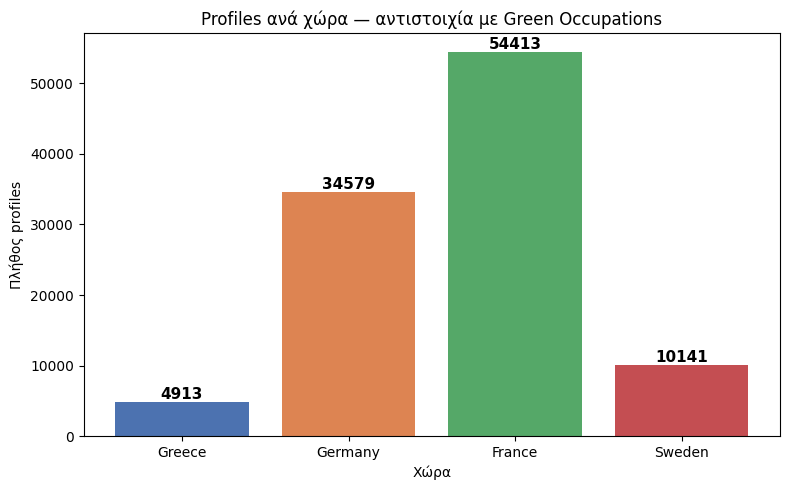

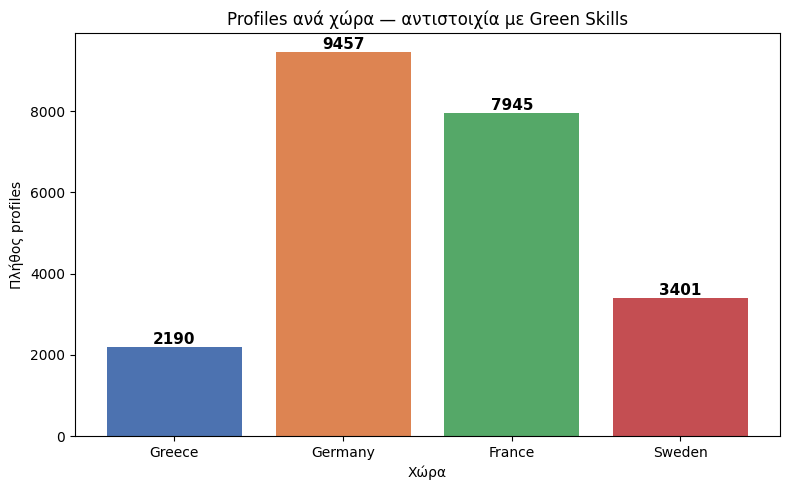

In [ ]:
import json
import matplotlib.pyplot as plt

# ── Αρχεία ανά χώρα, όπως προκύπτουν από τα δικά σου OUTPUT_FILE ──────────
occupation_files = {
    "Greece":  "skillab_profiles_greece_green_occupations.json",
    "Germany": "skillab_profiles_germany_green_occupations.json",
    "France":  "skillab_profiles_france_green_occupations.json",
    "Sweden":  "skillab_profiles_sweden_green_occupations.json",
}

skill_files = {
    "Greece":  "skillab_profiles_greece_green_skills.json",
    "Germany": "skillab_profiles_germany_green_skills.json",
    "France":  "skillab_profiles_france_green_skills.json",
    "Sweden":  "skillab_profiles_sweden_green_skills.json",
}


def load_counts(files_dict):
    counts = {}
    for country, filename in files_dict.items():
        try:
            with open(filename, "r", encoding="utf-8") as f:
                profiles = json.load(f)
            counts[country] = len(profiles)
        except FileNotFoundError:
            print(f"⚠️  Δεν βρέθηκε το αρχείο: {filename}")
            counts[country] = 0
    return counts


occupation_counts = load_counts(occupation_files)
skill_counts = load_counts(skill_files)

print("Green occupations - profiles ανά χώρα:", occupation_counts)
print("Green skills - profiles ανά χώρα:", skill_counts)

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

# ── Διάγραμμα 1: Profiles με βάση τα green occupations ────────────────────
plt.figure(figsize=(8, 5))
countries = list(occupation_counts.keys())
counts = list(occupation_counts.values())
bars = plt.bar(countries, counts, color=colors)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
              ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.title("Profiles ανά χώρα — αντιστοιχία με Green Occupations")
plt.ylabel("Πλήθος profiles")
plt.xlabel("Χώρα")
plt.tight_layout()
plt.show()

# ── Διάγραμμα 2: Profiles με βάση τα green skills ─────────────────────────
plt.figure(figsize=(8, 5))
countries = list(skill_counts.keys())
counts = list(skill_counts.values())
bars = plt.bar(countries, counts, color=colors)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
              ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.title("Profiles ανά χώρα — αντιστοιχία με Green Skills")
plt.ylabel("Πλήθος profiles")
plt.xlabel("Χώρα")
plt.tight_layout()
plt.show()

#Profiles in Romania

Αντιστοιχία με τα highly green occupations

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_romania_green_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Romania"]

# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
green_occupation_uris_set = set(green_occupation_uris)
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

OCCUPATION_URIS = green_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Romania' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "Romania" and profile.get("country") != "Romania":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & green_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} green occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Romania]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Romania + green occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Romania'], occupation_uris=(152 green occupation URIs, logic=or)


Fetching profiles [Romania]: 100%|██████████| 8001/8001 [19:48<00:00,  6.73profile/s, matched=8001, pages=161]

✅ API reported total profiles returned by server-side filters: 8001
✅ Profiles fetched/inspected: 8001
✅ Profiles that passed the client-side check (Romania + green occupation): 8001
✅ Saved profile data to skillab_profiles_romania_green_occupations.json


Αντιστοιχία με τα green skills

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_romania_green_skills.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Romania"]

# Φόρτωση της λίστας green skills (ESCO)
green_skills_df = pd.read_csv("/content/greenSkillsCollection_en.csv")
green_skill_uris = green_skills_df["conceptUri"].dropna().unique().tolist()
green_skill_uris_set = set(green_skill_uris)
print(f"Επίσημα green skill URIs: {len(green_skill_uris)}")

SKILL_IDS = green_skill_uris
SKILL_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Romania' ΚΑΙ τουλάχιστον ένα
    κοινό skill URI με τη λίστα των πράσινων skills (πεδίο 'skills' — επιβεβαιωμένο
    από το API response schema)."""
    if profile.get("location") != "Romania" and profile.get("country") != "Romania":
        return False
    profile_skill_uris = set(profile.get("skills") or [])
    return bool(profile_skill_uris & green_skill_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "skill_ids": SKILL_IDS,
    "skill_ids_logic": SKILL_IDS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, skill_ids=({len(SKILL_IDS)} green skill URIs, logic={SKILL_IDS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Romania]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Romania + green skill): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green skill URIs: 629
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Romania'], skill_ids=(629 green skill URIs, logic=or)


Fetching profiles [Romania]: 100%|██████████| 1470/1470 [01:22<00:00, 17.78profile/s, matched=1470, pages=30]

✅ API reported total profiles returned by server-side filters: 1470
✅ Profiles fetched/inspected: 1470
✅ Profiles that passed the client-side check (Romania + green skill): 1470
✅ Saved profile data to skillab_profiles_romania_green_skills.json


#Profiles in Czechia

Αντιστοιχία με τα highly green occupations

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_czechia_green_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Czech Republic"]

# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
green_occupation_uris_set = set(green_occupation_uris)
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

OCCUPATION_URIS = green_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Czech Republic' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "Czech Republic" and profile.get("country") != "Czech Republic":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & green_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} green occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Czechia]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Czechia + green occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Czech Republic'], occupation_uris=(152 green occupation URIs, logic=or)


Fetching profiles [Czechia]: 100%|██████████| 3066/3066 [08:31<00:00,  6.00profile/s, matched=3066, pages=62]

✅ API reported total profiles returned by server-side filters: 3066
✅ Profiles fetched/inspected: 3066
✅ Profiles that passed the client-side check (Czechia + green occupation): 3066
✅ Saved profile data to skillab_profiles_czechia_green_occupations.json


Αντιστοιχία με τα green skills

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_czechia_green_skills.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Czech Republic"]

# Φόρτωση της λίστας green skills (ESCO)
green_skills_df = pd.read_csv("/content/greenSkillsCollection_en.csv")
green_skill_uris = green_skills_df["conceptUri"].dropna().unique().tolist()
green_skill_uris_set = set(green_skill_uris)
print(f"Επίσημα green skill URIs: {len(green_skill_uris)}")

SKILL_IDS = green_skill_uris
SKILL_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Czech Republic' ΚΑΙ τουλάχιστον ένα
    κοινό skill URI με τη λίστα των πράσινων skills (πεδίο 'skills' — επιβεβαιωμένο
    από το API response schema)."""
    if profile.get("location") != "Czech Republic" and profile.get("country") != "Czech Republic":
        return False
    profile_skill_uris = set(profile.get("skills") or [])
    return bool(profile_skill_uris & green_skill_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "skill_ids": SKILL_IDS,
    "skill_ids_logic": SKILL_IDS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, skill_ids=({len(SKILL_IDS)} green skill URIs, logic={SKILL_IDS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Czech Republic]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Czech Republic + green skill): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green skill URIs: 629
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Czech Republic'], skill_ids=(629 green skill URIs, logic=or)


Fetching profiles [Czech Republic]: 100%|██████████| 768/768 [01:35<00:00,  8.05profile/s, matched=768, pages=16]

✅ API reported total profiles returned by server-side filters: 768
✅ Profiles fetched/inspected: 768
✅ Profiles that passed the client-side check (Czech Republic + green skill): 768
✅ Saved profile data to skillab_profiles_czechia_green_skills.json


Green occupations - profiles ανά χώρα: {'Greece': 4913, 'Germany': 34579, 'France': 54413, 'Sweden': 10141, 'Romania': 8001, 'Czechia': 3066}
Green skills - profiles ανά χώρα: {'Greece': 2190, 'Germany': 9457, 'France': 7945, 'Sweden': 3401, 'Romania': 1470, 'Czechia': 768}


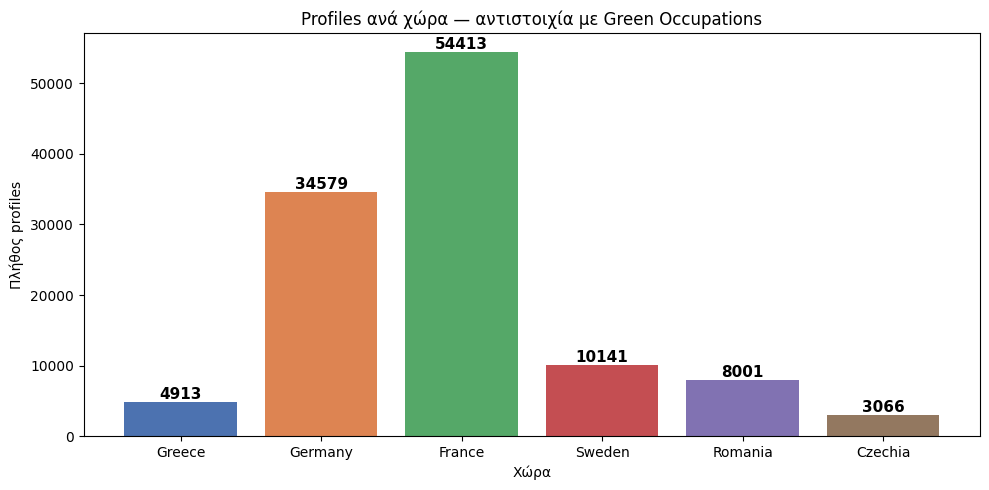

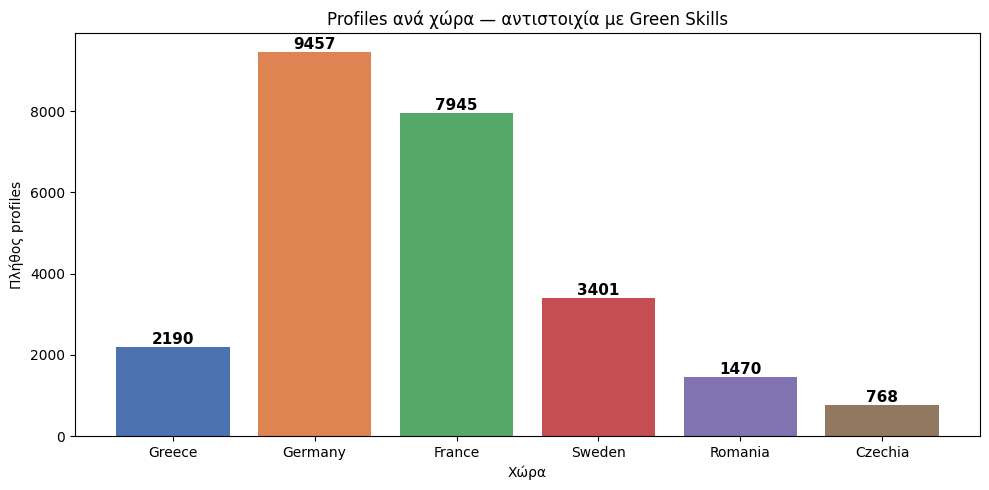

In [ ]:
import json
import matplotlib.pyplot as plt

# ── Αρχεία ανά χώρα, όπως προκύπτουν από τα δικά σου OUTPUT_FILE ──────────
occupation_files = {
    "Greece":  "skillab_profiles_greece_green_occupations.json",
    "Germany": "skillab_profiles_germany_green_occupations.json",
    "France":  "skillab_profiles_france_green_occupations.json",
    "Sweden":  "skillab_profiles_sweden_green_occupations.json",
    "Romania": "skillab_profiles_romania_green_occupations.json",
    "Czechia": "skillab_profiles_czechia_green_occupations.json",
}

skill_files = {
    "Greece":  "skillab_profiles_greece_green_skills.json",
    "Germany": "skillab_profiles_germany_green_skills.json",
    "France":  "skillab_profiles_france_green_skills.json",
    "Sweden":  "skillab_profiles_sweden_green_skills.json",
    "Romania": "skillab_profiles_romania_green_skills.json",
    "Czechia": "skillab_profiles_czechia_green_skills.json",
}


def load_counts(files_dict):
    counts = {}
    for country, filename in files_dict.items():
        try:
            with open(filename, "r", encoding="utf-8") as f:
                profiles = json.load(f)
            counts[country] = len(profiles)
        except FileNotFoundError:
            print(f"⚠️  Δεν βρέθηκε το αρχείο: {filename}")
            counts[country] = 0
    return counts


occupation_counts = load_counts(occupation_files)
skill_counts = load_counts(skill_files)

print("Green occupations - profiles ανά χώρα:", occupation_counts)
print("Green skills - profiles ανά χώρα:", skill_counts)

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

# ── Διάγραμμα 1: Profiles με βάση τα green occupations ────────────────────
plt.figure(figsize=(10, 5))
countries = list(occupation_counts.keys())
counts = list(occupation_counts.values())
bars = plt.bar(countries, counts, color=colors)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
              ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.title("Profiles ανά χώρα — αντιστοιχία με Green Occupations")
plt.ylabel("Πλήθος profiles")
plt.xlabel("Χώρα")
plt.tight_layout()
plt.show()

# ── Διάγραμμα 2: Profiles με βάση τα green skills ─────────────────────────
plt.figure(figsize=(10, 5))
countries = list(skill_counts.keys())
counts = list(skill_counts.values())
bars = plt.bar(countries, counts, color=colors)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
              ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.title("Profiles ανά χώρα — αντιστοιχία με Green Skills")
plt.ylabel("Πλήθος profiles")
plt.xlabel("Χώρα")
plt.tight_layout()
plt.show()

#Profiles in Poland

profiles filtering with green occupations

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_poland_green_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Poland"]

# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
green_occupation_uris_set = set(green_occupation_uris)
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

OCCUPATION_URIS = green_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Poland' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "Poland" and profile.get("country") != "Poland":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & green_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} green occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Poland]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Poland + green occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Poland'], occupation_uris=(152 green occupation URIs, logic=or)


Fetching profiles [Poland]: 100%|██████████| 8748/8748 [24:07<00:00,  6.04profile/s, matched=8748, pages=175]


✅ API reported total profiles returned by server-side filters: 8748
✅ Profiles fetched/inspected: 8748
✅ Profiles that passed the client-side check (Poland + green occupation): 8748
✅ Saved profile data to skillab_profiles_poland_green_occupations.json


profiles filtering with green skills

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_poland_green_skills.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Poland"]

# Φόρτωση της λίστας green skills (ESCO)
green_skills_df = pd.read_csv("/content/greenSkillsCollection_en.csv")
green_skill_uris = green_skills_df["conceptUri"].dropna().unique().tolist()
green_skill_uris_set = set(green_skill_uris)
print(f"Επίσημα green skill URIs: {len(green_skill_uris)}")

SKILL_IDS = green_skill_uris
SKILL_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Poland' ΚΑΙ τουλάχιστον ένα
    κοινό skill URI με τη λίστα των πράσινων skills (πεδίο 'skills' — επιβεβαιωμένο
    από το API response schema)."""
    if profile.get("location") != "Poland" and profile.get("country") != "Poland":
        return False
    profile_skill_uris = set(profile.get("skills") or [])
    return bool(profile_skill_uris & green_skill_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "skill_ids": SKILL_IDS,
    "skill_ids_logic": SKILL_IDS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, skill_ids=({len(SKILL_IDS)} green skill URIs, logic={SKILL_IDS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Poland]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Poland + green skill): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green skill URIs: 629
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Poland'], skill_ids=(629 green skill URIs, logic=or)


Fetching profiles [Poland]: 100%|██████████| 2123/2123 [02:42<00:00, 13.10profile/s, matched=2123, pages=43]


✅ API reported total profiles returned by server-side filters: 2123
✅ Profiles fetched/inspected: 2123
✅ Profiles that passed the client-side check (Poland + green skill): 2123
✅ Saved profile data to skillab_profiles_poland_green_skills.json


#Profiles in Spain

profiles filtering with green occupations

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_spain_green_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Spain"]

# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
green_occupation_uris_set = set(green_occupation_uris)
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

OCCUPATION_URIS = green_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Spain' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "Spain" and profile.get("country") != "Spain":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & green_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} green occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Spain]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Spain + green occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Spain'], occupation_uris=(152 green occupation URIs, logic=or)


Fetching profiles [Spain]: 100%|██████████| 27715/27715 [1:07:50<00:00,  6.81profile/s, matched=27715, pages=555]


✅ API reported total profiles returned by server-side filters: 27715
✅ Profiles fetched/inspected: 27715
✅ Profiles that passed the client-side check (Spain + green occupation): 27715
✅ Saved profile data to skillab_profiles_spain_green_occupations.json


profiles filtering with green skills

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_spain_green_skills.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Spain"]

# Φόρτωση της λίστας green skills (ESCO)
green_skills_df = pd.read_csv("/content/greenSkillsCollection_en.csv")
green_skill_uris = green_skills_df["conceptUri"].dropna().unique().tolist()
green_skill_uris_set = set(green_skill_uris)
print(f"Επίσημα green skill URIs: {len(green_skill_uris)}")

SKILL_IDS = green_skill_uris
SKILL_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Spain' ΚΑΙ τουλάχιστον ένα
    κοινό skill URI με τη λίστα των πράσινων skills (πεδίο 'skills' — επιβεβαιωμένο
    από το API response schema)."""
    if profile.get("location") != "Spain" and profile.get("country") != "Spain":
        return False
    profile_skill_uris = set(profile.get("skills") or [])
    return bool(profile_skill_uris & green_skill_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "skill_ids": SKILL_IDS,
    "skill_ids_logic": SKILL_IDS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, skill_ids=({len(SKILL_IDS)} green skill URIs, logic={SKILL_IDS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Spain]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Spain + green skill): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green skill URIs: 629
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Spain'], skill_ids=(629 green skill URIs, logic=or)


Fetching profiles [Spain]: 100%|██████████| 6707/6707 [09:06<00:00, 12.28profile/s, matched=6707, pages=135]


✅ API reported total profiles returned by server-side filters: 6707
✅ Profiles fetched/inspected: 6707
✅ Profiles that passed the client-side check (Spain + green skill): 6707
✅ Saved profile data to skillab_profiles_spain_green_skills.json



#Profiles Italy

profiles filtering with green occupations

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_italy_green_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Italy"]

# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
green_occupation_uris_set = set(green_occupation_uris)
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

OCCUPATION_URIS = green_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Italy' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "Italy" and profile.get("country") != "Italy":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & green_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} green occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Italy]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Italy + green occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Italy'], occupation_uris=(152 green occupation URIs, logic=or)


Fetching profiles [Italy]: 100%|██████████| 37331/37331 [1:19:22<00:00,  7.84profile/s, matched=37331, pages=747]


✅ API reported total profiles returned by server-side filters: 37331
✅ Profiles fetched/inspected: 37331
✅ Profiles that passed the client-side check (Italy + green occupation): 37331
✅ Saved profile data to skillab_profiles_italy_green_occupations.json


profiles filtering with green skills

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_italy_green_skills.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Italy"]

# Φόρτωση της λίστας green skills (ESCO)
green_skills_df = pd.read_csv("/content/greenSkillsCollection_en.csv")
green_skill_uris = green_skills_df["conceptUri"].dropna().unique().tolist()
green_skill_uris_set = set(green_skill_uris)
print(f"Επίσημα green skill URIs: {len(green_skill_uris)}")

SKILL_IDS = green_skill_uris
SKILL_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Italy' ΚΑΙ τουλάχιστον ένα
    κοινό skill URI με τη λίστα των πράσινων skills (πεδίο 'skills' — επιβεβαιωμένο
    από το API response schema)."""
    if profile.get("location") != "Italy" and profile.get("country") != "Italy":
        return False
    profile_skill_uris = set(profile.get("skills") or [])
    return bool(profile_skill_uris & green_skill_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "skill_ids": SKILL_IDS,
    "skill_ids_logic": SKILL_IDS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, skill_ids=({len(SKILL_IDS)} green skill URIs, logic={SKILL_IDS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Italy]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Italy + green skill): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα green skill URIs: 629
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Italy'], skill_ids=(629 green skill URIs, logic=or)


Fetching profiles [Italy]: 100%|██████████| 7018/7018 [08:49<00:00, 13.25profile/s, matched=7018, pages=141]


✅ API reported total profiles returned by server-side filters: 7018
✅ Profiles fetched/inspected: 7018
✅ Profiles that passed the client-side check (Italy + green skill): 7018
✅ Saved profile data to skillab_profiles_italy_green_skills.json


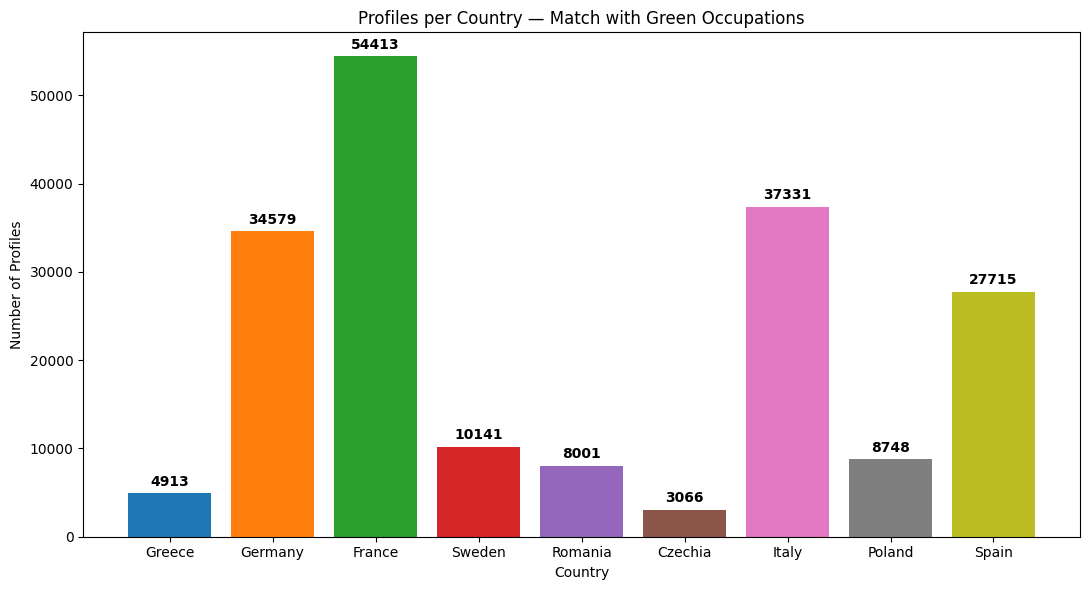

In [9]:
import json
import matplotlib.pyplot as plt

# Dictionary with file paths for each country
occupation_files = {
    "Greece":  "skillab_profiles_greece_green_occupations.json",
    "Germany": "skillab_profiles_germany_green_occupations.json",
    "France":  "skillab_profiles_france_green_occupations.json",
    "Sweden":  "skillab_profiles_sweden_green_occupations.json",
    "Romania": "skillab_profiles_romania_green_occupations.json",
    "Czechia": "skillab_profiles_czechia_green_occupations.json",
    "Poland":  "skillab_profiles_poland_green_occupations.json",
    "Italy":   "skillab_profiles_italy_green_occupations.json",
    "Spain":   "skillab_profiles_spain_green_occupations.json",
}

# Only the countries we want in this plot (original 6 + Italy + Poland)
countries_to_plot = ["Greece", "Germany", "France", "Sweden", "Romania", "Czechia", "Italy", "Poland", "Spain"]

# Count number of records (profiles) in each file
counts = {}
for country in countries_to_plot:
    file_path = occupation_files[country]
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    counts[country] = len(data)  # assumes each file is a JSON list of profiles

# Prepare data for plotting
countries = list(counts.keys())
values = list(counts.values())

# Plot
plt.figure(figsize=(11, 6))
bars = plt.bar(countries, values, color=plt.cm.tab10.colors[:len(countries)])

# Add value labels on top of each bar
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.01,
        f"{value}",
        ha="center", va="bottom", fontweight="bold"
    )

plt.title("Profiles per Country — Match with Green Occupations")
plt.xlabel("Country")
plt.ylabel("Number of Profiles")
plt.tight_layout()
plt.show()